In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#import warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#we will use some methods from the sklearn module
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score

In [ ]:
#reading the dataset
df = pd.read_csv("/content/drive/MyDrive/data.csv")

In [ ]:
df.head()

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105


In [ ]:
df.shape

(36, 5)

In [ ]:
print(df[["Volume","Weight","CO2"]].corr())

          Volume    Weight       CO2
Volume  1.000000  0.753537  0.592082
Weight  0.753537  1.000000  0.552150
CO2     0.592082  0.552150  1.000000


In [ ]:
print(df.describe())

            Volume       Weight         CO2
count    36.000000    36.000000   36.000000
mean   1611.111111  1292.277778  102.027778
std     388.975047   242.123889    7.454571
min     900.000000   790.000000   90.000000
25%    1475.000000  1117.250000   97.750000
50%    1600.000000  1329.000000   99.000000
75%    2000.000000  1418.250000  105.000000
max    2500.000000  1746.000000  120.000000


In [ ]:
#setting value for x and y
x = df[["Volume","Weight"]]
y = df["CO2"]

# check outliers

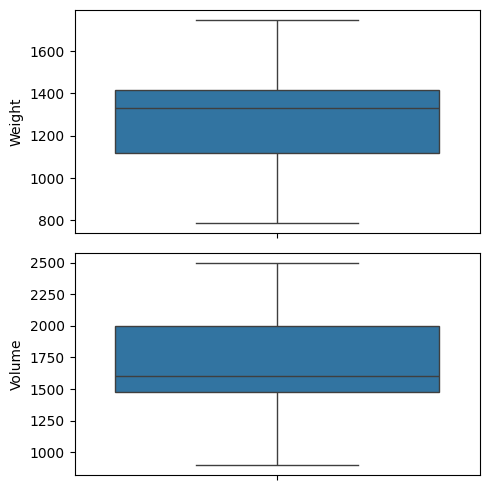

In [ ]:
fig, axs = plt.subplots(2,figsize = (5,5))
plt1 = sns.boxplot (df["Weight"], ax = axs[0])
plt2 = sns.boxplot (df["Volume"], ax = axs[1])
plt.tight_layout()

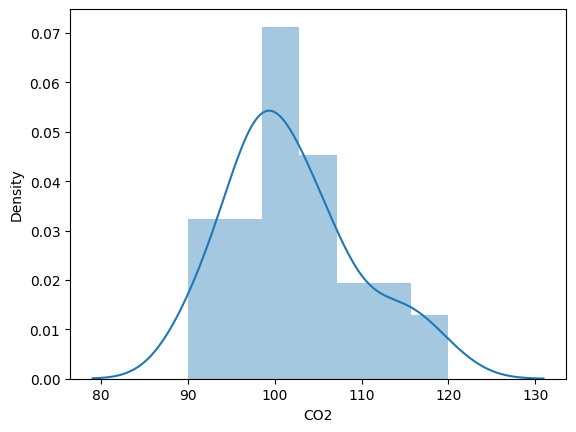

In [ ]:
sns.distplot(df["CO2"]);

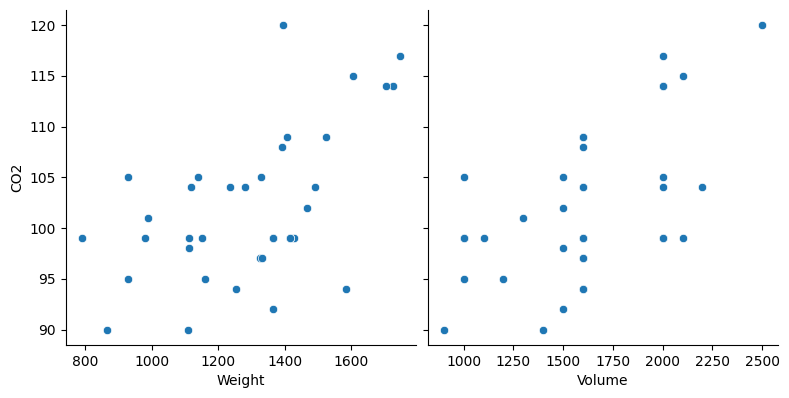

In [ ]:
sns.pairplot(df, x_vars=["Weight","Volume"], y_vars="CO2", height=4, aspect=1, kind="scatter")
plt.show()

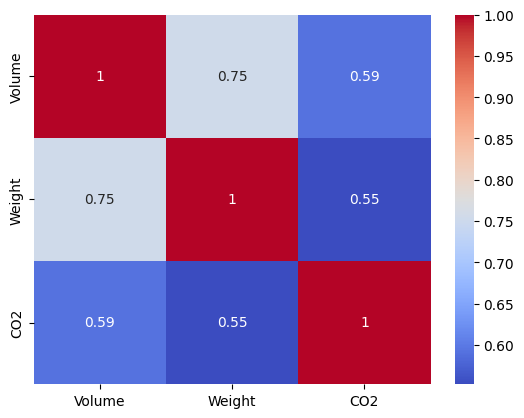

In [ ]:
#create the correlation matrix and represent it as heatmap
sns.heatmap(df[["Volume","Weight","CO2"]].corr(), annot=True, cmap="coolwarm")
plt.show()

model building splitting the dataset into train and test set

We need to split out dataset into training and testing sets. we'll perform this by importing train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=100)

In [ ]:
y_train.shape
(25,)

y_test.shape
(11,)

(11,)

In [ ]:
reg_model = linear_model.LinearRegression()

In [ ]:
reg_model = LinearRegression().fit(x_train, y_train)

In [ ]:
print("Intercept:" , reg_model.intercept_)


Intercept: 74.33882836589247


In [ ]:
#pair the feature names with the coefficients
list(zip(x, reg_model.coef_))

[('Volume', np.float64(0.0025046399866402932)),
 ('Weight', np.float64(0.017180064599637404))]

In [ ]:
#predicting the test and train set result
y_pred = reg_model.predict(x_test)
x_pred = reg_model.predict(x_train)

In [ ]:
print("Prediction for test set:{}". format(y_pred))

Prediction for test set:[ 90.41571939 102.16323413  99.56363213 104.56661845 101.54657652
  95.94770019 108.64011848 102.22654214  92.80374837  97.27327129
  97.57074463]


In [ ]:
#actual value and the pre3dicted value
reg_model_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred})
reg_model_diff

,Actual value,Predicted value
0,99,90.415719
19,105,102.163234
32,104,99.563632
35,120,104.566618
7,92,101.546577
12,99,95.947700
29,114,108.640118
33,108,102.226542
5,105,92.803748
1,95,97.273271


In [ ]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print("mean absolute error:", mae)
print("mean squared error:", mse)
print("root mean squared error:", r2)

mean absolute error: 6.90198090163631
mean squared error: 63.39765310998782
root mean squared error: 7.962264320530173
